In [1]:
from google.colab import files
uploaded = files.upload()

Saving loan_prediction.csv to loan_prediction.csv


In [2]:
import pandas as pd

df = pd.read_csv('loan_prediction.csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [4]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [5]:
df.describe(include='all')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614,601,611,599,614,582,614.000000,614.000000,592.000000,600.00000,564.000000,614,614
unique,614,2,2,4,2,2,NaN,NaN,NaN,NaN,NaN,3,2
top,LP002990,Male,Yes,0,Graduate,No,NaN,NaN,NaN,NaN,NaN,Semiurban,Y
freq,1,489,398,345,480,500,NaN,NaN,NaN,NaN,NaN,233,422
mean,NaN,NaN,NaN,NaN,NaN,NaN,5403.459283,1621.245798,146.412162,342.00000,0.842199,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6109.041673,2926.248369,85.587325,65.12041,0.364878,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,150.000000,0.000000,9.000000,12.00000,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2877.500000,0.000000,100.000000,360.00000,1.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,3812.500000,1188.500000,128.000000,360.00000,1.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,5795.000000,2297.250000,168.000000,360.00000,1.000000,NaN,NaN


In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
# Fill categorical columns with mode

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

# Fill numerical columns with median

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())

print(df.isnull().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [8]:
print(df['Loan_Status'].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [10]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(491, 12)
(123, 12)


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision :", precision_score(y_test,y_pred_lr))
print("Recall :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))
print("ROC AUC :", roc_auc_score(y_test,y_pred_lr))

Accuracy : 0.7886178861788617
Precision : 0.7596153846153846
Recall : 0.9875
F1 Score : 0.8586956521739131
ROC AUC : 0.7030523255813954


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [16]:
print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision :", precision_score(y_test,y_pred_rf))
print("Recall :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test,y_pred_rf))

Accuracy : 0.7804878048780488
Precision : 0.7572815533980582
Recall : 0.975
F1 Score : 0.8524590163934426
ROC AUC : 0.6968023255813953


In [17]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest'],
    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf)
    ],
    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf)
    ],
    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf)
    ],
    'ROC AUC':[
        roc_auc_score(y_test,y_pred_lr),
        roc_auc_score(y_test,y_pred_rf)
    ]
})

print(results)

                 Model  Precision  Recall  F1 Score   ROC AUC
0  Logistic Regression   0.759615  0.9875  0.858696  0.703052
1        Random Forest   0.757282  0.9750  0.852459  0.696802


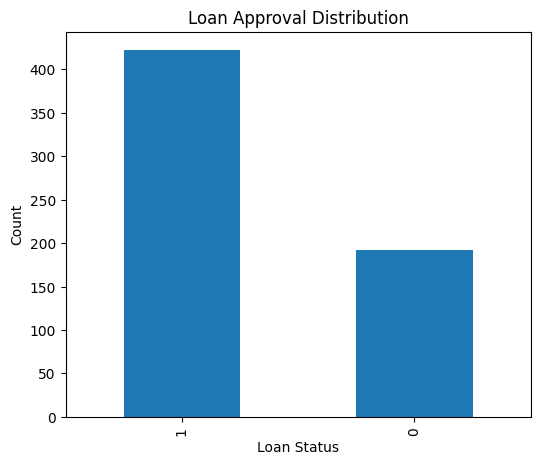

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

df['Loan_Status'].value_counts().plot(
    kind='bar'
)

plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

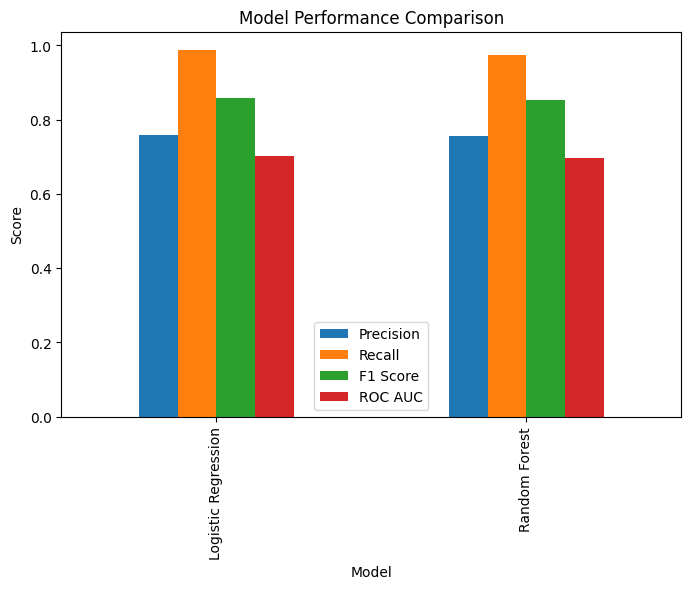

In [19]:
results.set_index('Model')[['Precision','Recall','F1 Score','ROC AUC']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')

plt.show()

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

Loan_Status
0    342
1    342
Name: count, dtype: int64


In [21]:
lr.fit(X_train_smote, y_train_smote)

LogisticRegression()

In [22]:
rf.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=42)

In [24]:
y_pred_lr = lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test,y_pred_lr))
print("Precision :", precision_score(y_test,y_pred_lr))
print("Recall :", recall_score(y_test,y_pred_lr))
print("F1 Score :", f1_score(y_test,y_pred_lr))
print("ROC AUC :", roc_auc_score(y_test,y_pred_lr))

Accuracy : 0.7642276422764228
Precision : 0.7684210526315789
Recall : 0.9125
F1 Score : 0.8342857142857143
ROC AUC : 0.7004360465116279


In [25]:
y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test,y_pred_rf))
print("Precision :", precision_score(y_test,y_pred_rf))
print("Recall :", recall_score(y_test,y_pred_rf))
print("F1 Score :", f1_score(y_test,y_pred_rf))
print("ROC AUC :", roc_auc_score(y_test,y_pred_rf))

Accuracy : 0.7479674796747967
Precision : 0.7578947368421053
Recall : 0.9
F1 Score : 0.8228571428571428
ROC AUC : 0.6825581395348836
